# A1 Fatal Traffic Accidents — Risk Factor Analysis
**Source**: stg_accidents (PostgreSQL)  
**Goal**: 以隨機森林識別影響多人死亡事故的關鍵風險因子

> **注意**：受限於樣本數（416起），模型結果僅供方向性參考，不宜過度解讀。

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sqlalchemy import create_engine

# 中文字型設定
_candidates = ['PingFang HK', 'PingFang SC', 'Heiti TC', 'STHeiti',
               'Hiragino Sans GB', 'Arial Unicode MS']
_available  = {f.name for f in fm.fontManager.ttflist}
_match      = next((f for f in _candidates if f in _available), None)
if _match:
    _font_path = fm.findfont(fm.FontProperties(family=_match))
    fm.fontManager.addfont(_font_path)
    _font_name = fm.FontProperties(fname=_font_path).get_name()
    sns.set_theme(style='whitegrid', rc={
        'font.family': 'sans-serif',
        'font.sans-serif': [_font_name, 'DejaVu Sans'],
        'axes.unicode_minus': False,
    })

engine = create_engine(
    'postgresql://postgres@localhost:5432/postgres',
    connect_args={'options': '-csearch_path=A1_Traffic_Fatal'}
)
print('Connected.')

Connected.


## 1. 載入與準備資料

In [2]:
df = pd.read_sql('SELECT * FROM "A1_Traffic_Fatal".stg_accidents', engine)
acc = df[df['party_order'] == 1].copy()

# 目標變數：多人死亡 = 1，單人死亡 = 0
acc['multi_death'] = (acc['death_count'] > 1).astype(int)
print(f'目標變數分布：\n{acc["multi_death"].value_counts()}')

目標變數分布：
multi_death
0    406
1     10
Name: count, dtype: int64


## 2. 特徵工程

In [3]:
features = [
    'accident_hour',
    'accident_month',
    'weather',
    'road_condition',
    'signal_type',
    'road_form_major',
    'accident_type_major',
    'speed_limit',
    'is_hit_and_run',
]

X = acc[features].copy()
y = acc['multi_death']

# 類別欄位 Label Encoding
cat_cols = ['weather', 'road_condition', 'signal_type',
            'road_form_major', 'accident_type_major']

le = LabelEncoder()
for col in cat_cols:
    X[col] = X[col].fillna('未知')
    X[col] = le.fit_transform(X[col])

X['is_hit_and_run'] = X['is_hit_and_run'].astype(int)
X['speed_limit']    = X['speed_limit'].fillna(X['speed_limit'].median())

print(f'特徵矩陣 shape: {X.shape}')
X.head(3)

特徵矩陣 shape: (416, 9)


,accident_hour,accident_month,weather,road_condition,signal_type,road_form_major,accident_type_major,speed_limit,is_hit_and_run
0,5,1,2,1,1,1,2,50,1
4,6,1,2,1,2,0,0,50,0
6,9,1,0,0,0,1,2,40,0


## 3. 訓練隨機森林

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    class_weight='balanced',  # 處理類別不平衡
    random_state=42
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['單人死亡', '多人死亡']))

              precision    recall  f1-score   support

        單人死亡       0.98      0.99      0.98        82
        多人死亡       0.00      0.00      0.00         2

    accuracy                           0.96        84
   macro avg       0.49      0.49      0.49        84
weighted avg       0.95      0.96      0.96        84



## 4. 特徵重要性（最核心的輸出）

                 特徵      重要性
      accident_hour 0.295144
        speed_limit 0.150372
    road_form_major 0.130461
     accident_month 0.122804
            weather 0.106976
accident_type_major 0.105875
        signal_type 0.069931
     road_condition 0.017265
     is_hit_and_run 0.001171


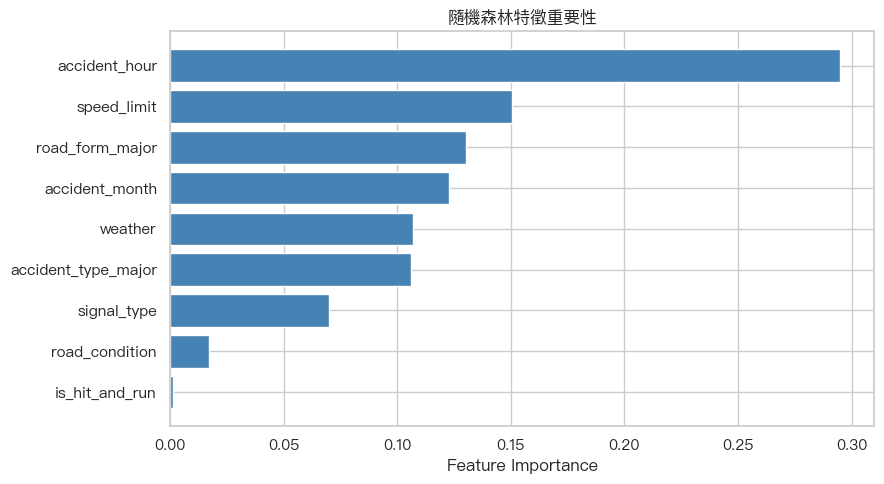

In [5]:
importance_df = pd.DataFrame({
    '特徵':   features,
    '重要性': rf.feature_importances_
}).sort_values('重要性', ascending=False)

print(importance_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importance_df['特徵'][::-1], importance_df['重要性'][::-1], color='steelblue')
ax.set_xlabel('Feature Importance')
ax.set_title('隨機森林特徵重要性')
plt.tight_layout()
plt.savefig('../Images/feature_importance.png', dpi=150)
plt.show()

## 5. Confusion Matrix

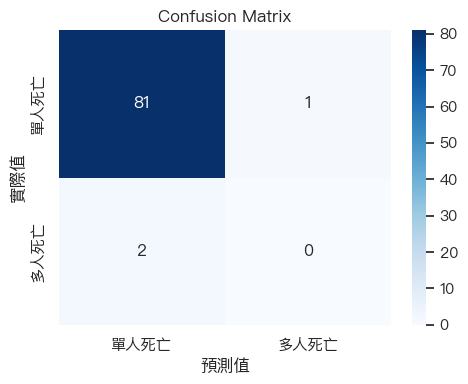

In [6]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['單人死亡', '多人死亡'],
            yticklabels=['單人死亡', '多人死亡'], ax=ax)
ax.set_xlabel('預測值')
ax.set_ylabel('實際值')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('../Images/confusion_matrix.png', dpi=150)
plt.show()

## 6. 結果解讀與限制說明

In [7]:
print('=== 模型限制說明 ===')
print(f'樣本數: {len(acc)} 起事故')
print(f'多人死亡樣本數: {acc["multi_death"].sum()} 起 ({acc["multi_death"].mean()*100:.1f}%)')
print()
print('受限於樣本數量，模型預測力有限。')
print('特徵重要性的參考價值高於預測準確率本身，')
print('可用於識別「哪些因素與多人死亡事故最相關」的方向性結論。')
print()
print('=== Top 3 風險因子 ===')
for _, row in importance_df.head(3).iterrows():
    print(f'  {row["特徵"]}: {row["重要性"]:.4f}')

=== 模型限制說明 ===
樣本數: 416 起事故
多人死亡樣本數: 10 起 (2.4%)

受限於樣本數量，模型預測力有限。
特徵重要性的參考價值高於預測準確率本身，
可用於識別「哪些因素與多人死亡事故最相關」的方向性結論。

=== Top 3 風險因子 ===
  accident_hour: 0.2951
  speed_limit: 0.1504
  road_form_major: 0.1305
